In [ ]:
import pandas as pd
import numpy as np
import pyreadr
import warnings
warnings.filterwarnings('ignore')

# Modelos
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Evaluación
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    confusion_matrix, accuracy_score, classification_report
)

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
print('Librerías cargadas correctamente.')

In [25]:
import sklearn
print(sklearn.__version__)

1.8.0


In [ ]:
# Carga del dataset
result = pyreadr.read_r('listings.RData')
df_raw = list(result.values())[0].copy()

print(f'Filas: {df_raw.shape[0]} | Columnas: {df_raw.shape[1]}')
df_raw.head(3)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,city
0,5456.0,https://www.airbnb.com/rooms/5456,2.025092e+13,2025-09-17,city scrape,"Walk to 6th, Rainey St and Convention Ctr",Great central location for walking to Convent...,My neighborhood is ideally located if you want...,https://a0.muscache.com/pictures/14084884/b5a3...,8028,...,4.73,4.79,NaN,f,1,1,0,0,3.52,"Austin, Texas"
1,6448.0,https://www.airbnb.com/rooms/6448,2.025092e+13,2025-09-17,city scrape,"Secluded Studio @ Zilker - King Bed, Bright & ...","Clean, private space with everything you need ...",The neighborhood is fun and funky (but quiet)!...,https://a0.muscache.com/pictures/airflow/Hosti...,14156,...,4.97,4.88,NaN,t,1,1,0,0,1.98,"Austin, Texas"
2,8502.0,https://www.airbnb.com/rooms/8502,2.025092e+13,2025-09-17,city scrape,Woodland Studio Lodging,Studio rental on lower level of home located i...,,https://a0.muscache.com/pictures/miso/Hosting-...,25298,...,4.69,4.63,NaN,f,1,1,0,0,0.28,"Austin, Texas"
3,13035.0,https://www.airbnb.com/rooms/13035,2.025092e+13,2025-09-17,city scrape,Historic house in highly walkable East Austin,Comfortable 2 bedroom/2 bathroom home very cen...,East Cesar Chavez is a gentrifying urban area ...,https://a0.muscache.com/pictures/miso/Hosting-...,50793,...,5.00,4.95,NaN,f,2,2,0,0,0.11,"Austin, Texas"
4,22828.0,https://www.airbnb.com/rooms/22828,2.025092e+13,2025-09-16,city scrape,Garage Apartment central SE Austin,"Fully furnished, centrally located, second sto...","wikipedia: East_Riverside-Oltorf,_Austin,_Texas",https://a0.muscache.com/pictures/miso/Hosting-...,56488,...,4.72,4.84,NaN,f,1,1,0,0,0.30,"Austin, Texas"


In [ ]:
# ── Preprocesamiento general ─────────────────────────────────────────────────
df = df_raw.copy()
df.columns = df.columns.str.strip()

# Limpiar columna price: eliminar $ y comas
df['price'] = df['price'].replace('[\$,]', '', regex=True)
df['price'] = pd.to_numeric(df['price'], errors='coerce')

# Eliminar columnas no útiles (texto libre / identificadores)
cols_drop = ['id', 'host_id', 'listing_url', 'name', 'description',
             'neighborhood_overview', 'picture_url', 'host_url',
             'host_name', 'host_about', 'host_thumbnail_url',
             'host_picture_url', 'calendar_updated', 'last_scraped']
df = df.drop(columns=[c for c in cols_drop if c in df.columns])

# Eliminar columnas de fecha (no útiles sin ingeniería de features extra)
date_cols = [c for c in df.columns if 'date' in c.lower() or 'since' in c.lower()]
df = df.drop(columns=date_cols, errors='ignore')

# Columnas booleanas t/f → 1/0
for col in df.select_dtypes(include='object').columns:
    vals = df[col].dropna().unique()
    if set(vals).issubset({'t', 'f'}):
        df[col] = df[col].map({'t': 1, 'f': 0})

# Porcentajes → numérico
for col in df.select_dtypes(include='object').columns:
    if df[col].astype(str).str.contains('%', na=False).any():
        df[col] = df[col].astype(str).str.replace('%', '', regex=False)
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding de categóricas con cardinalidad baja
cat_cols = df.select_dtypes(include='object').columns.tolist()
cat_validas = [c for c in cat_cols if df[c].nunique() < 20]
df = pd.get_dummies(df, columns=cat_validas, drop_first=True)

# Eliminar restantes de texto libre
remaining_obj = df.select_dtypes(include='object').columns.tolist()
df = df.drop(columns=remaining_obj, errors='ignore')

# Eliminar filas con nulos
df = df.dropna(subset=['price'])

# Eliminar outliers extremos de precio (por encima del percentil 99)
p99 = df['price'].quantile(0.99)
df = df[df['price'] <= p99]

print(f'Dataset limpio → Filas: {df.shape[0]} | Columnas: {df.shape[1]}')
df['price'].describe()

<>:5: SyntaxWarning: invalid escape sequence '\$'
<>:5: SyntaxWarning: invalid escape sequence '\$'
C:\Users\max75\AppData\Local\Temp\ipykernel_17424\960769905.py:5: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace('[\$,]', '', regex=True)
C:\Users\max75\AppData\Local\Temp\ipykernel_17424\960769905.py:15: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df.select_dtypes(include=['object']).columns


In [28]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=123
)


In [29]:
arbol = DecisionTreeRegressor(random_state=123)
arbol.fit(X_train, y_train)

pred = arbol.predict(X_test)

In [30]:
mse = mean_squared_error(y_test, pred)
rmse = np.sqrt(mse)

mae = mean_absolute_error(y_test, pred)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 2045.9352726103884
MAE: 218.94444444444446


In [31]:
mejor_modelo = DecisionTreeRegressor(max_depth=10, random_state=123)
mejor_modelo.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",123
,"max_le

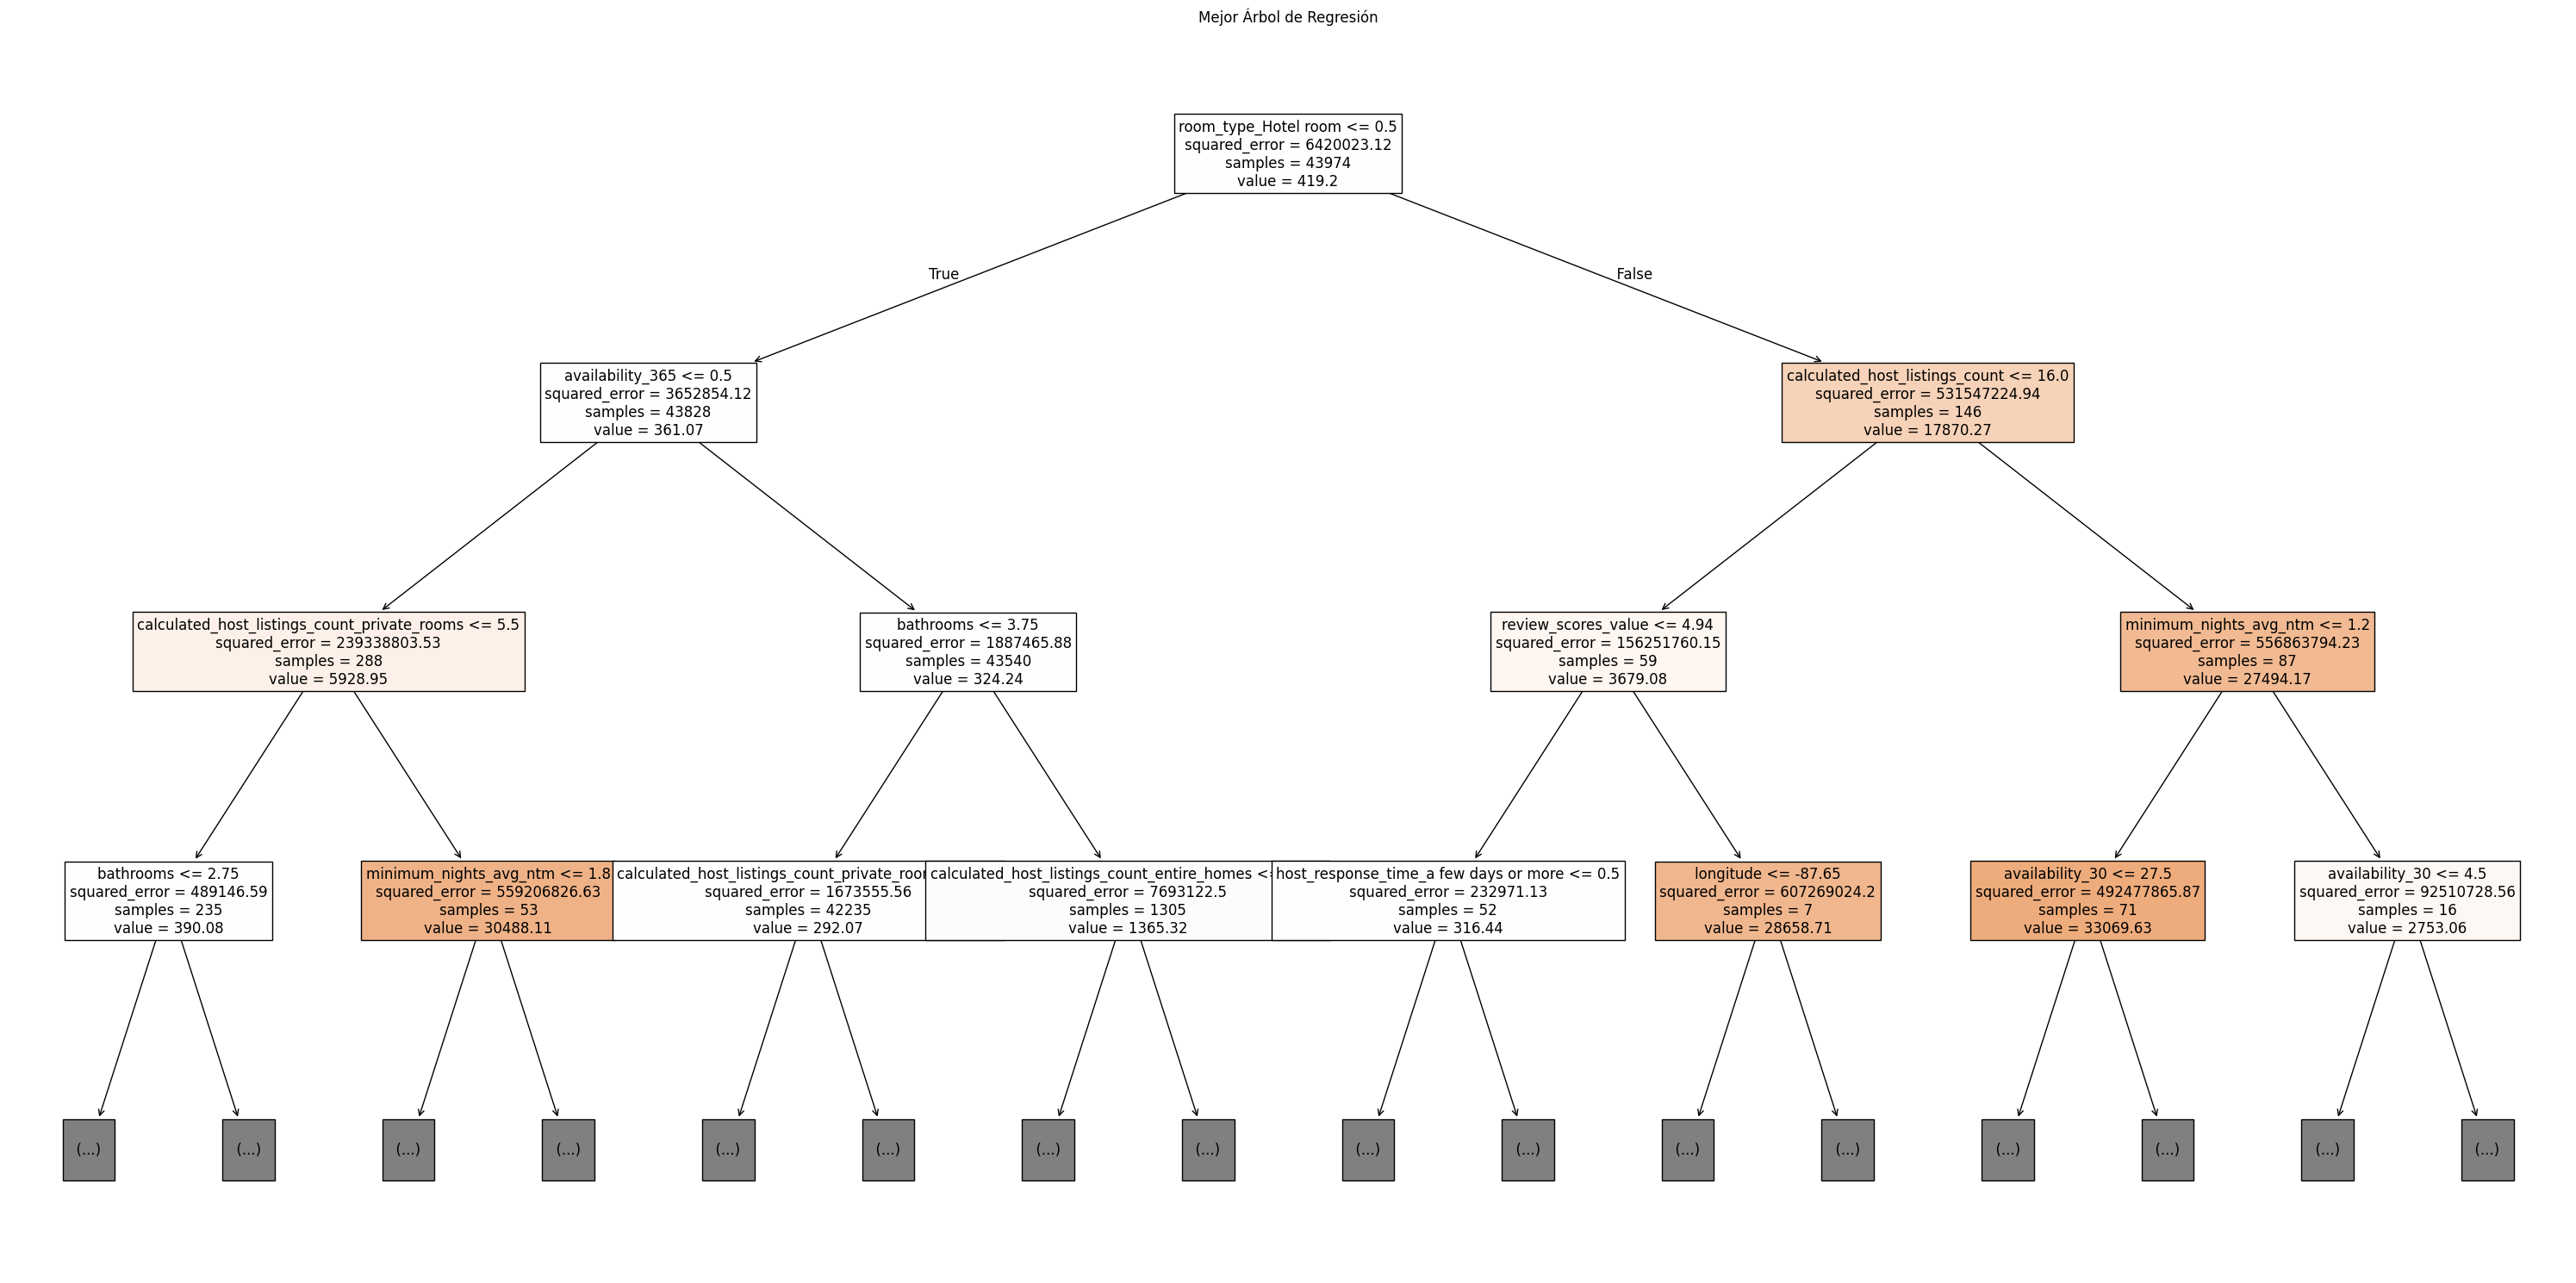

In [ ]:
%matplotlib inline

plt.figure(figsize=(30,15)) 

plot_tree(
    mejor_modelo, 
    filled=True, 
    feature_names=list(X.columns),  
    max_depth=3,
    fontsize=12,  
    precision=2
)

plt.title("Mejor Árbol de Regresión")

plt.tight_layout()
plt.show()

In [ ]:
resultados = {}

for depth in [3, 5, 10, None]:
    modelo = DecisionTreeRegressor(max_depth=depth, random_state=123)
    modelo.fit(X_train, y_train)
    
    pred = modelo.predict(X_test)
    
    mse = mean_squared_error(y_test, pred)
    rmse = np.sqrt(mse)
    
    resultados[depth] = rmse

print(resultados)

{3: np.float64(1941.0838656776214), 5: np.float64(1836.4402457332635), 10: np.float64(1827.1881150634754), None: np.float64(2045.9352726103884)}


In [ ]:
lm = LinearRegression()
lm.fit(X_train, y_train)

pred_lm = lm.predict(X_test)

mse_lm = mean_squared_error(y_test, pred_lm)
rmse_lm = np.sqrt(mse_lm)

print("RMSE Regresión Lineal:", rmse_lm)

RMSE Regresión Lineal: 1901.8061658989736


In [35]:
df_clas['price'] = df_clas['price'].replace('[\$,]', '', regex=True)

<>:1: SyntaxWarning: invalid escape sequence '\$'
<>:1: SyntaxWarning: invalid escape sequence '\$'
C:\Users\max75\AppData\Local\Temp\ipykernel_17424\1664397892.py:1: SyntaxWarning: invalid escape sequence '\$'
  df_clas['price'] = df_clas['price'].replace('[\$,]', '', regex=True)


In [ ]:
result = pyreadr.read_r('listings.RData')
df_clas = list(result.values())[0]

df_clas.columns = df_clas.columns.str.strip()
df_clas['price'] = df_clas['price'].replace('[\$,]', '', regex=True)
df_clas['price'] = pd.to_numeric(df_clas['price'], errors='coerce')

def clasificar_precio(x):
    if x < 50:
        return "Economica"
    elif x < 150:
        return "Intermedia"
    else:
        return "Cara"

df_clas['precio_cat'] = df_clas['price'].apply(clasificar_precio)

<>:7: SyntaxWarning: invalid escape sequence '\$'
<>:7: SyntaxWarning: invalid escape sequence '\$'
C:\Users\max75\AppData\Local\Temp\ipykernel_17424\474172868.py:7: SyntaxWarning: invalid escape sequence '\$'
  df_clas['price'] = df_clas['price'].replace('[\$,]', '', regex=True)


In [37]:
df_clas = df_clas.drop(columns=[
    'id', 'host_id', 'listing_url', 'name', 'description',
    'neighborhood_overview'
], errors='ignore')

categoricas = df_clas.select_dtypes(include=['object']).columns

categoricas_validas = []
for col in categoricas:
    if df_clas[col].nunique() < 20 and col != 'precio_cat':
        categoricas_validas.append(col)

df_clas = pd.get_dummies(df_clas, columns=categoricas_validas, drop_first=True)

df_clas = df_clas.drop(columns=[col for col in categoricas if col not in categoricas_validas and col != 'precio_cat'], errors='ignore')

df_clas = df_clas.dropna()

C:\Users\max75\AppData\Local\Temp\ipykernel_17424\3217238110.py:6: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df_clas.select_dtypes(include=['object']).columns


In [ ]:
categoricas = df_clas.select_dtypes(include=['object']).columns

categoricas = [col for col in categoricas if col != 'precio_cat']

categoricas_validas = []
for col in categoricas:
    if df_clas[col].nunique() < 20:
        categoricas_validas.append(col)

df_clas = pd.get_dummies(df_clas, columns=categoricas_validas, drop_first=True)

df_clas = df_clas.drop(columns=[col for col in categoricas if col not in categoricas_validas], errors='ignore')

df_clas = df_clas.dropna()

C:\Users\max75\AppData\Local\Temp\ipykernel_17424\3348202066.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categoricas = df_clas.select_dtypes(include=['object']).columns


In [39]:
X_clas = df_clas.drop(columns=['precio_cat'])
y_clas = df_clas['precio_cat']

X_train_clas, X_test_clas, y_train_clas, y_test_clas = train_test_split(
    X_clas, y_clas, test_size=0.3, random_state=123
)

In [40]:
clf = DecisionTreeClassifier(random_state=123)
clf.fit(X_train_clas, y_train_clas)

pred_clf = clf.predict(X_test_clas)

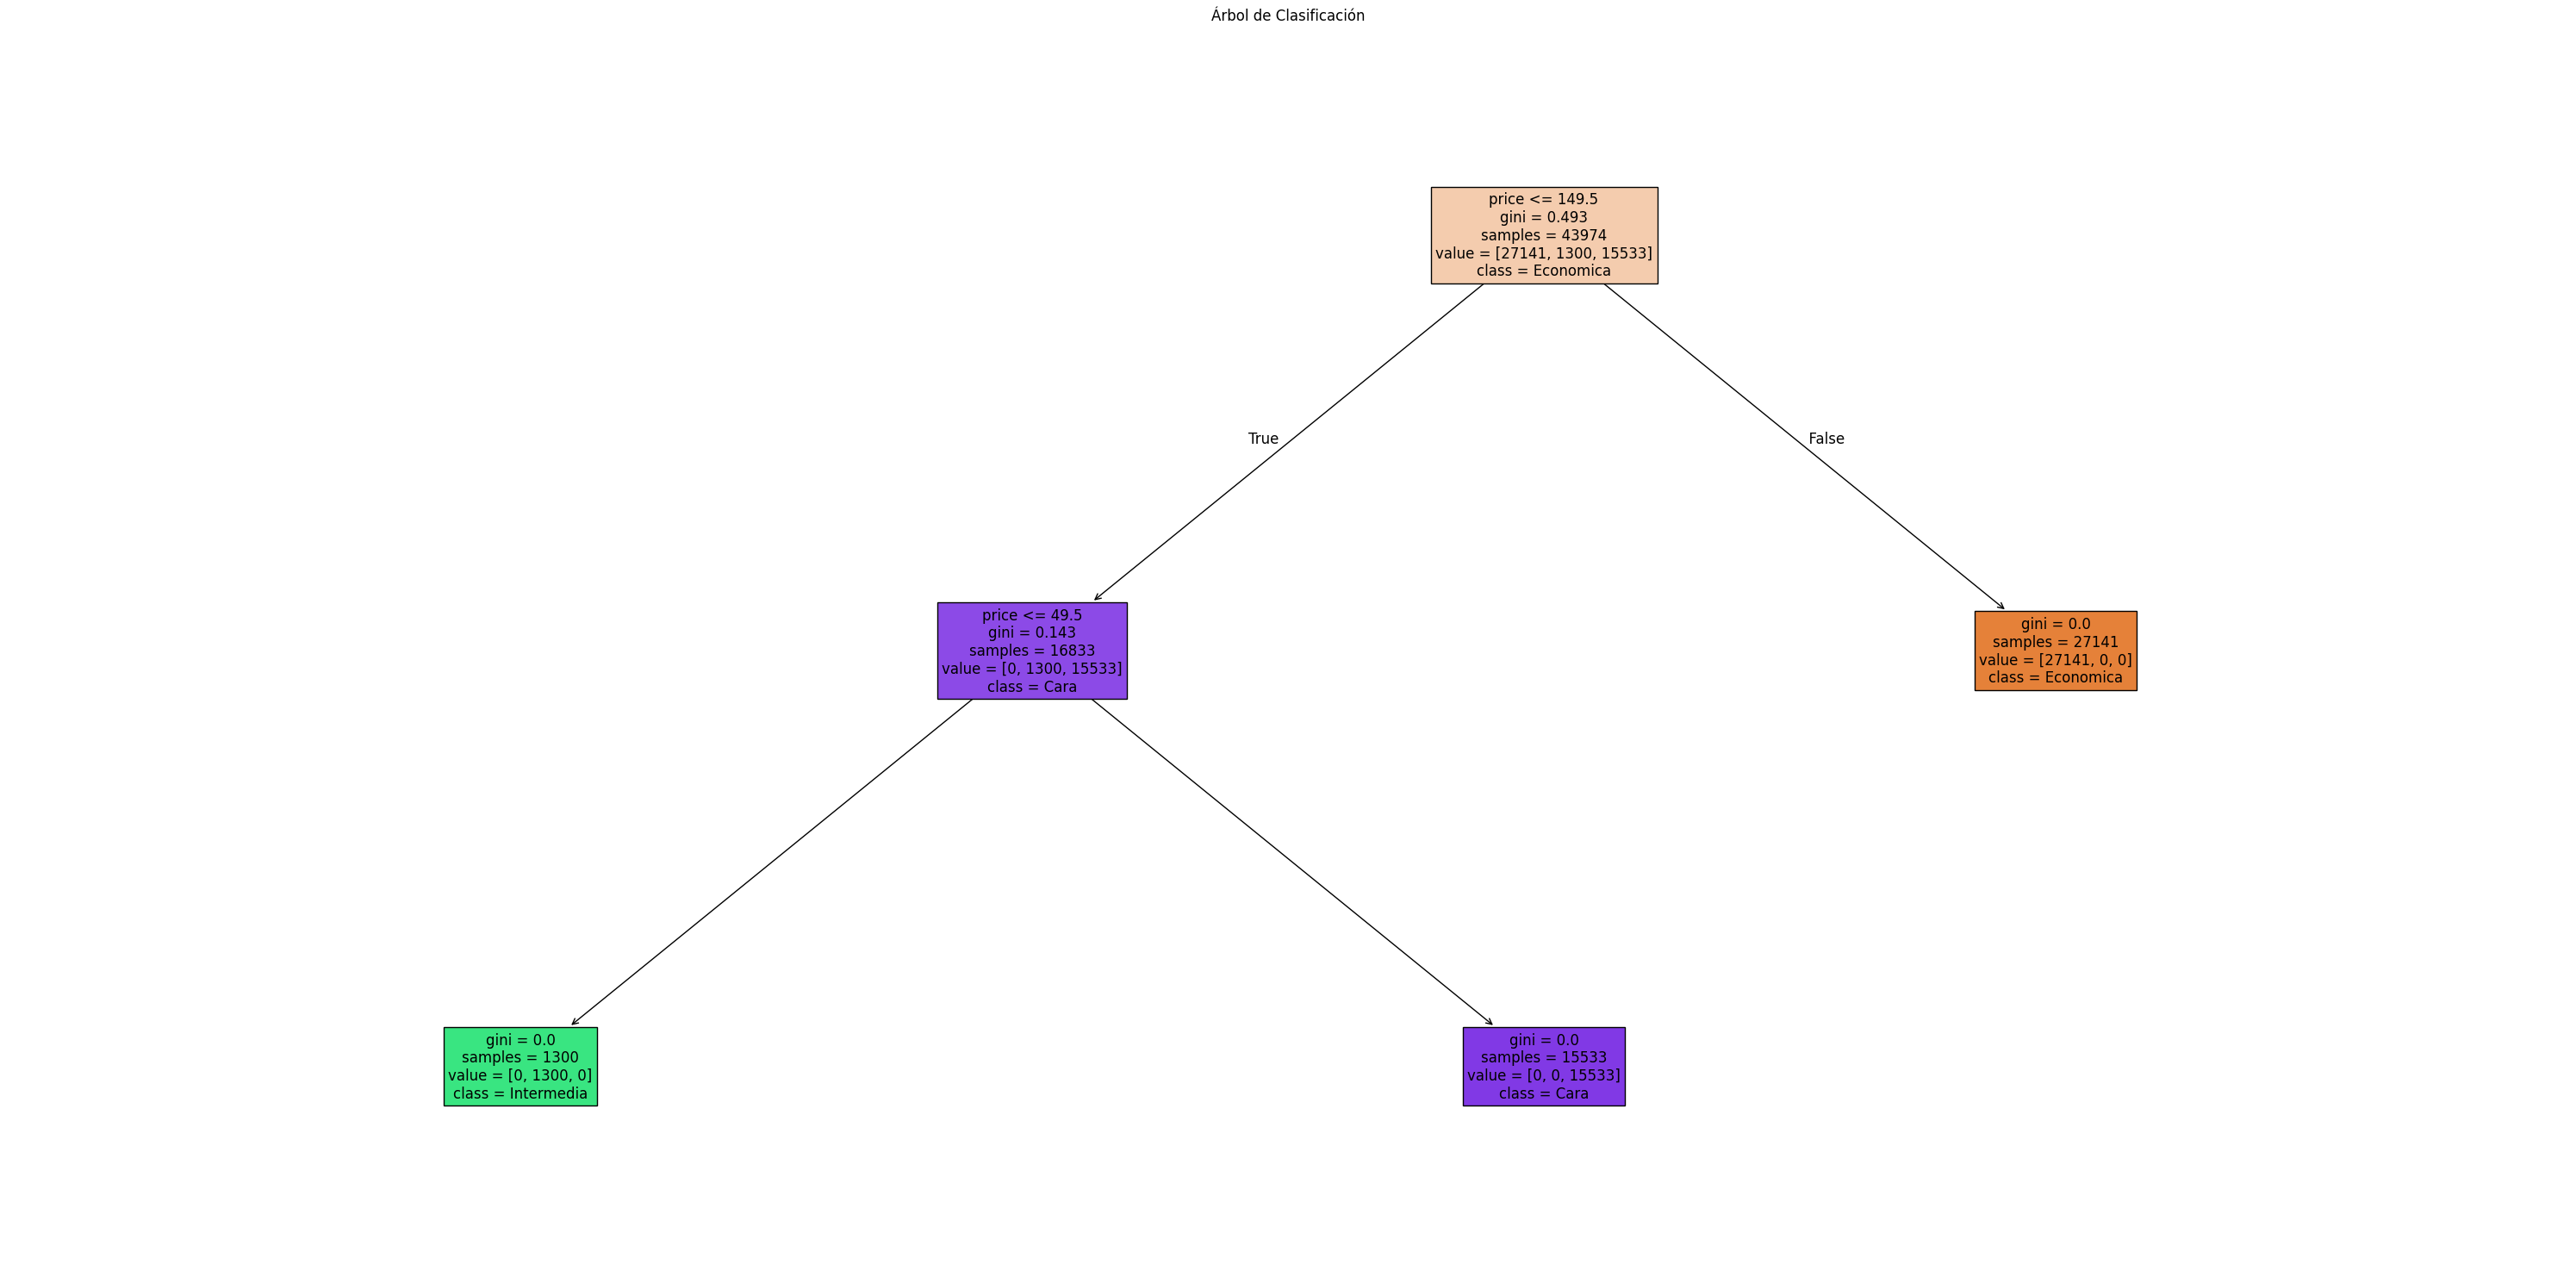

In [41]:
%matplotlib inline

plt.figure(figsize=(30,15))
plot_tree(clf, filled=True, feature_names=list(X_clas.columns), class_names=['Economica', 'Intermedia', 'Cara'], max_depth=3, fontsize=12)
plt.title("Árbol de Clasificación")
plt.tight_layout()
plt.show()